In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/skin-cancer-mnist-ham10000/hmnist_8_8_RGB.csv
/kaggle/input/skin-cancer-mnist-ham10000/hmnist_28_28_RGB.csv
/kaggle/input/skin-cancer-mnist-ham10000/hmnist_8_8_L.csv
/kaggle/input/skin-cancer-mnist-ham10000/hmnist_28_28_L.csv
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028394.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027799.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028100.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027960.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028872.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0026412.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0024872.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000

In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
import numpy as np
import pandas as pd
import os
from tensorflow.keras.utils import to_categorical
from glob import glob

In [5]:
df = pd.read_csv('/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv')

In [6]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [7]:
df.describe()

,age
count,9958.000000
mean,51.863828
std,16.968614
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


In [8]:
df.dtypes

lesion_id        object
image_id         object
dx               object
dx_type          object
age             float64
sex              object
localization     object
dtype: object

In [9]:
df.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

In [10]:
df['age'].fillna(int(df['age'].median()),inplace=True)

/tmp/ipykernel_30/1565346434.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(int(df['age'].median()),inplace=True)


In [11]:
df.isnull().sum()

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dtype: int64

In [12]:
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions ',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}
base_skin_dir = '/kaggle/input/skin-cancer-mnist-ham10000'

# Merge images from both folders into one dictionary

imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x
                     for x in glob(os.path.join(base_skin_dir, '*', '*.jpg'))}

In [13]:
len(imageid_path_dict)

10015

In [14]:
df['path'] = df['image_id'].map(imageid_path_dict.get)
df['cell_type'] = df['dx'].map(lesion_type_dict.get) 
df['cell_type_idx'] = pd.Categorical(df['cell_type']).codes
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,Benign keratosis-like lesions,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,Benign keratosis-like lesions,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,Benign keratosis-like lesions,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,Benign keratosis-like lesions,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,Benign keratosis-like lesions,2


In [15]:
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet import MobileNet
from tensorflow.keras.models import Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
# Split data into training and testing sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['dx'])

In [16]:
# Create an ImageDataGenerator for preprocessing and augmentation
datagen = ImageDataGenerator(rescale=1./255)

# Load training data in batches from DataFrame
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='dx',
    target_size=(224, 224),  # Image size for MobileNet
    batch_size=16,
    class_mode='categorical'  # or 'binary' depending on your labels
)

# Load test data in batches from DataFrame
test_generator = datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='dx',
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',  # or 'binary'
    shuffle=False
)


Found 8012 validated image filenames belonging to 7 classes.
Found 2003 validated image filenames belonging to 7 classes.


In [28]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Load pre-trained MobileNet without top layers
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Fine-tune MobileNet: Unfreeze the top few layers
base_model.trainable = True  # Unfreeze the entire model

# Optionally, freeze the bottom layers and keep only the top layers trainable
for layer in base_model.layers[:-20]:  # Unfreeze the last 20 layers, change this based on your need
    layer.trainable = False
    
num_classes = len(train_generator.class_indices) 

# Add new top layers (GlobalAveragePooling2D and Dense)
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Pool the features
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax')(x)  # Number of classes = number of lesion types

# Create the new model with the fine-tuned MobileNet
model = Model(inputs=base_model.input, outputs=output)

# Compile the model with a low learning rate
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=5,          # Stop training if no improvement after 5 epochs
    restore_best_weights=True  # Restore weights from the best epoch
)

# Create a feature extractor model from MobileNet
# model = Model(inputs=base_model.input, outputs=base_model.layers[-1].output)
history = model.fit(
    train_generator,
    validation_data=test_generator,  # Provide a validation generator for monitoring
    epochs=50,                       # Set a high maximum epoch count
    callbacks=[early_stopping]       # Add early stopping callback
)


# Function to extract features using MobileNet for a batch of images
def extract_features(generator, model):
    features = []
    labels = []
    
    for batch_x, batch_y in generator:
        feature_batch = model.predict(batch_x, verbose=0)  # Set verbose=0 to suppress progress bar
        feature_batch = feature_batch.reshape(feature_batch.shape[0], -1)  # Flatten
        features.append(feature_batch)
        labels.append(batch_y)
        
        if len(features) * generator.batch_size >= generator.samples:
            break
    
    features = np.vstack(features)
    labels = np.vstack(labels)
    return features, labels

# Extract features for training and testing sets
X_train, y_train = extract_features(train_generator, model)
X_test, y_test = extract_features(test_generator, model)


Epoch 1/50
  3/501 ━━━━━━━━━━━━━━━━━━━━ 36s 74ms/step - accuracy: 0.0382 - loss: 4.2016      

I0000 00:00:1734004932.129761     107 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_divide_multiply_subtract_fusion_6', 4 bytes spill stores, 4 bytes spill loads



501/501 ━━━━━━━━━━━━━━━━━━━━ 86s 155ms/step - accuracy: 0.5558 - loss: 1.4713 - val_accuracy: 0.7733 - val_loss: 0.6811
Epoch 2/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 65s 129ms/step - accuracy: 0.7430 - loss: 0.6969 - val_accuracy: 0.7853 - val_loss: 0.6026
Epoch 3/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 65s 128ms/step - accuracy: 0.7974 - loss: 0.5683 - val_accuracy: 0.8028 - val_loss: 0.5843
Epoch 4/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 65s 128ms/step - accuracy: 0.8383 - loss: 0.4460 - val_accuracy: 0.7943 - val_loss: 0.6338
Epoch 5/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 65s 128ms/step - accuracy: 0.8794 - loss: 0.3435 - val_accuracy: 0.8193 - val_loss: 0.5300
Epoch 6/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 65s 128ms/step - accuracy: 0.9049 - loss: 0.2740 - val_accuracy: 0.7958 - val_loss: 0.5883
Epoch 7/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 66s 130ms/step - accuracy: 0.9171 - loss: 0.2316 - val_accuracy: 0.8018 - val_loss: 0.5669
Epoch 8/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 65s 129ms/step - accuracy: 0.9384 - loss: 0.1836 - val

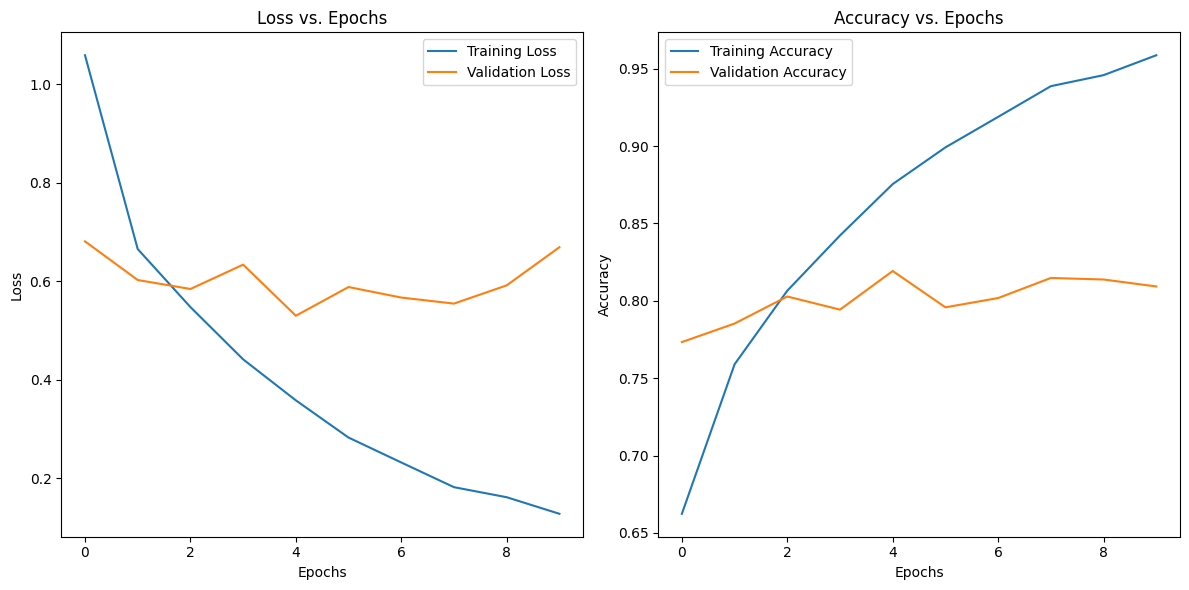

In [29]:
# Plot the training progress
def plot_training_progress(history):
    plt.figure(figsize=(12, 6))
    
    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss vs. Epochs')
    plt.legend()
    
    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs. Epochs')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Call the function to plot
plot_training_progress(history)

In [30]:
# Normalize features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
y_train

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], dtype=float32)

In [32]:
if y_train.ndim > 1:
    y_train = np.argmax(y_train, axis=1)
    y_test = np.argmax(y_test, axis=1)
y_train

array([5, 5, 3, ..., 0, 5, 1])

In [33]:
y_test

array([5, 5, 4, ..., 4, 4, 5])

In [34]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Fit the model on the training data
xgb_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = xgb_model.predict(X_test_scaled)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"XGBoost Classification accuracy: {accuracy * 100:.2f}%")

XGBoost Classification accuracy: 82.58%


126/126 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step


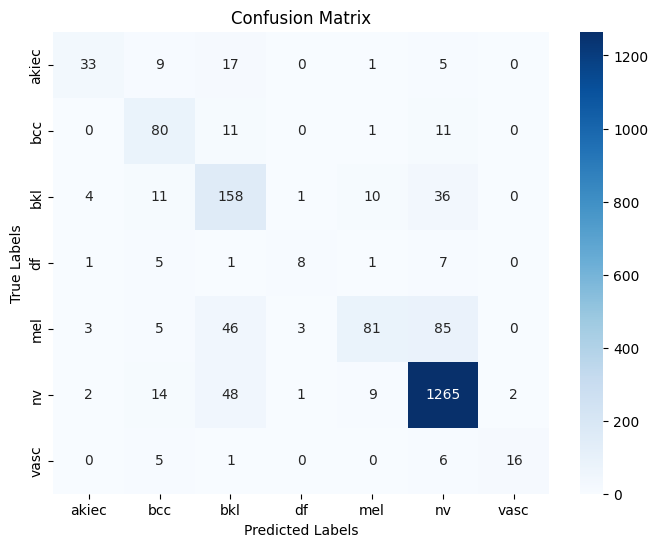

Classification Report:

              precision    recall  f1-score   support

       akiec       0.77      0.51      0.61        65
         bcc       0.62      0.78      0.69       103
         bkl       0.56      0.72      0.63       220
          df       0.62      0.35      0.44        23
         mel       0.79      0.36      0.50       223
          nv       0.89      0.94      0.92      1341
        vasc       0.89      0.57      0.70        28

    accuracy                           0.82      2003
   macro avg       0.73      0.60      0.64      2003
weighted avg       0.82      0.82      0.81      2003



In [35]:
from sklearn.metrics import classification_report, confusion_matrix

# Ensure y_test is a 1D array of class indices
if len(y_test.shape) > 1:
    y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded to class indices
else:
    y_true = y_test

# Ensure y_pred is a 1D array of class indices
predictions = model.predict(test_generator)
if len(predictions.shape) > 1:
    y_pred = np.argmax(predictions, axis=1)  # Convert probabilities to class indices
else:
    y_pred = predictions

# Generate confusion matrix and classification report
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Generate classification report
class_report = classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys())
print("Classification Report:\n")
print(class_report)


In [13]:
df['image'] = df['path'].map(lambda x: np.asarray(Image.open(x).resize((128,128))))

KeyboardInterrupt: 

In [ ]:
n_samples = 5
fig, m_axs = plt.subplots(7, n_samples, figsize = (4*n_samples, 3*7))
for n_axs, (type_name, type_rows) in zip(m_axs, 
                                         df.sort_values(['cell_type']).groupby('cell_type')):
    n_axs[0].set_title(type_name)
    for c_ax, (_, c_row) in zip(n_axs, type_rows.sample(n_samples, random_state=2018).iterrows()):
        c_ax.imshow(c_row['image'])
        c_ax.axis('off')
fig.savefig('category_samples.png', dpi=300)

In [ ]:
df['image'].map(lambda x: x.shape).value_counts()

<Axes: title={'center': 'CELL TYPE'}, xlabel='cell_type', ylabel='Count'>

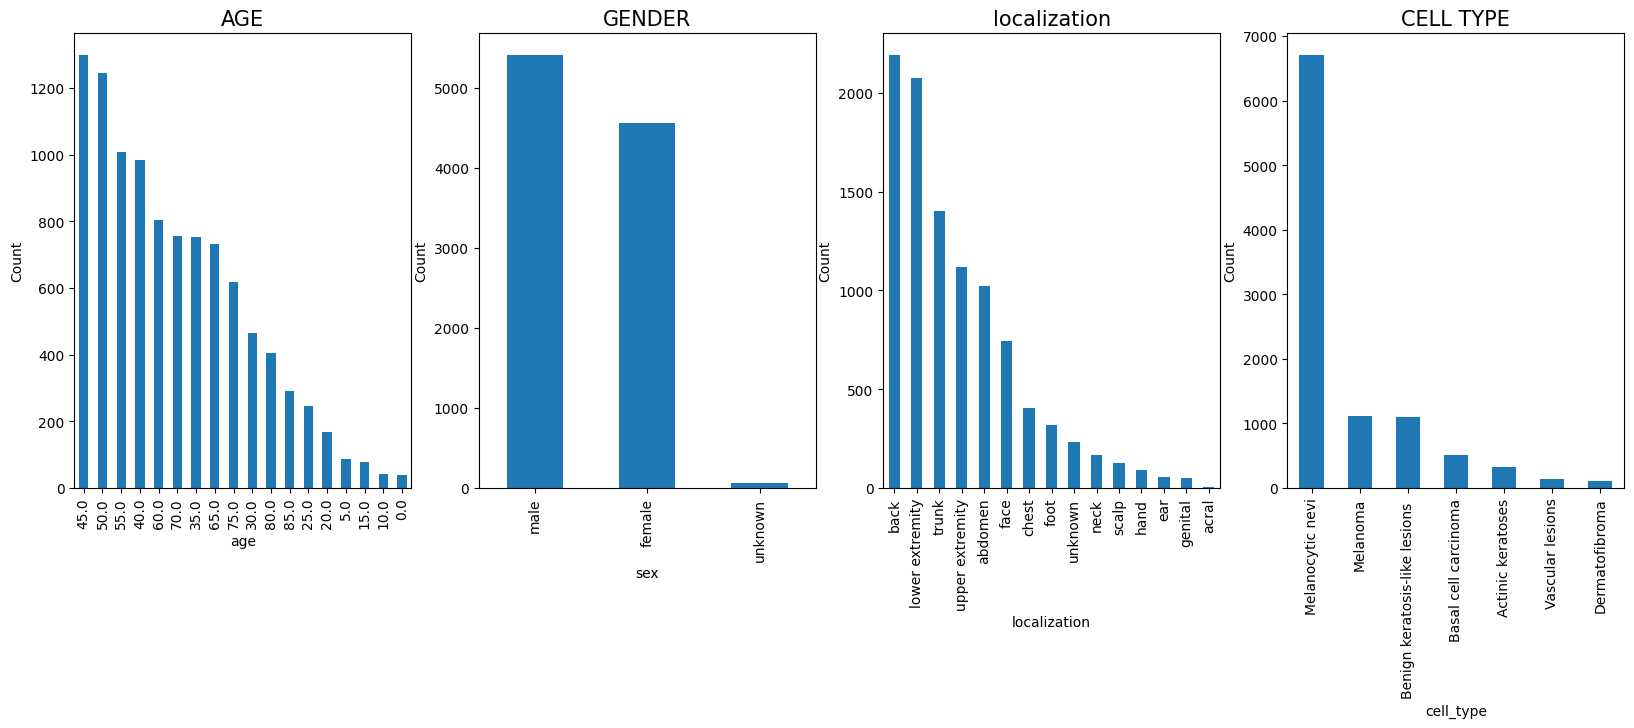

In [16]:
plt.figure(figsize=(20,10))
plt.subplots_adjust(left=0.125, bottom=1, right=0.9, top=2, hspace=0.2)
plt.subplot(2,4,1)
plt.title("AGE",fontsize=15)
plt.ylabel("Count")
df['age'].value_counts().plot.bar()

plt.subplot(2,4,2)
plt.title("GENDER",fontsize=15)
plt.ylabel("Count")
df['sex'].value_counts().plot.bar()

plt.subplot(2,4,3)
plt.title("localization",fontsize=15)
plt.ylabel("Count")
plt.xticks(rotation=45)
df['localization'].value_counts().plot.bar()

plt.subplot(2,4,4)
plt.title("CELL TYPE",fontsize=15)
plt.ylabel("Count")
df['cell_type'].value_counts().plot.bar()

Skin diseases are found to be maximum in people aged around 45. Minimum for 10 and below. We also observe that the probability of having skin disease increases with the increase in age.
Skin diseases are more prominent in Men as compared to Women and other gender.
Skin diseases are more visible on the "back" of the body and least on the "acral surfaces"(such as limbs, fingers, or ears).
The most found disease among people is Melanocytic nevi while the least found is Dermatofibroma.

<Axes: title={'center': 'LOCALIZATION VS GENDER'}, xlabel='count', ylabel='localization'>

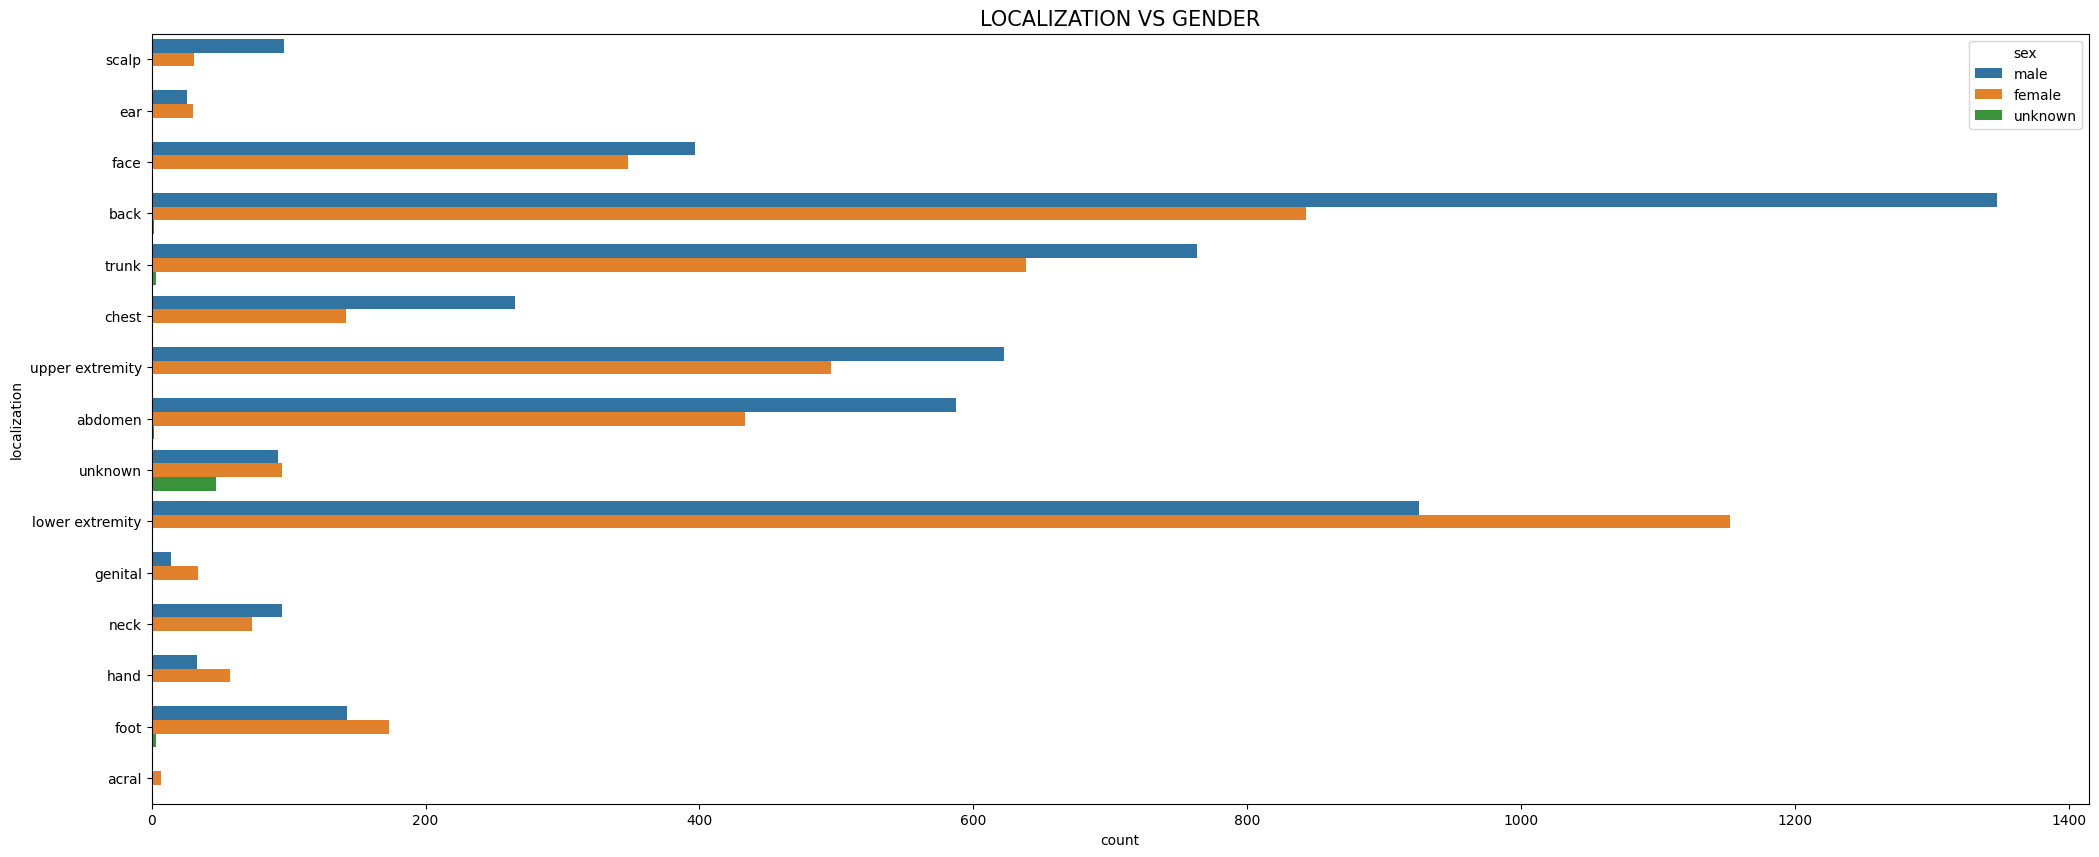

In [17]:
plt.figure(figsize=(25,10))
plt.title('LOCALIZATION VS GENDER',fontsize = 15)
sns.countplot(y='localization', hue='sex',data=df)

<Axes: title={'center': 'LOCALIZATION VS CELL TYPE'}, xlabel='count', ylabel='localization'>

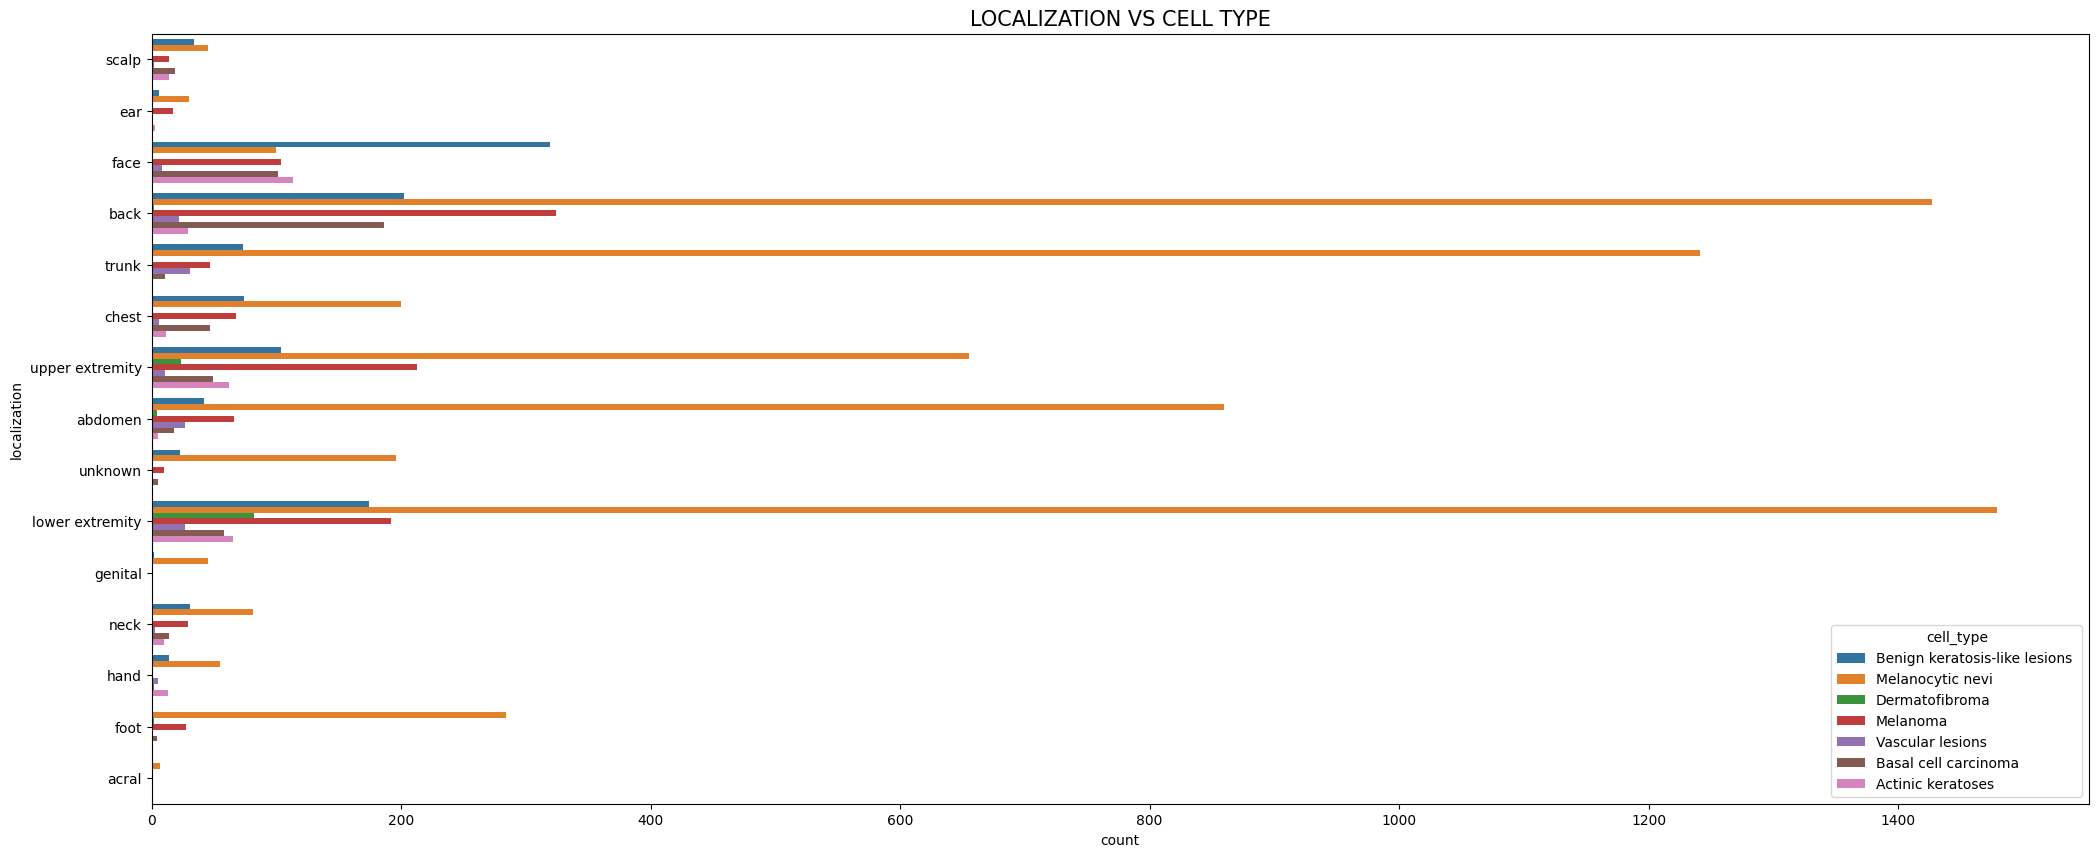

In [18]:
plt.figure(figsize=(25,10))
plt.title('LOCALIZATION VS CELL TYPE',fontsize = 15)
sns.countplot(y='localization', hue='cell_type',data=df)

Back are is the most affected among people and more prominent in men.
Infection on Lower extremity of the body is more visible in women.
Some unknown regions also show infections and it's visible in men, women and other genders.
The acral surfaces show the least infection cases that too in men only. Other gender groups don't show this kind of infection.

<Axes: title={'center': 'GENDER VS CELL TYPE'}, xlabel='count', ylabel='sex'>

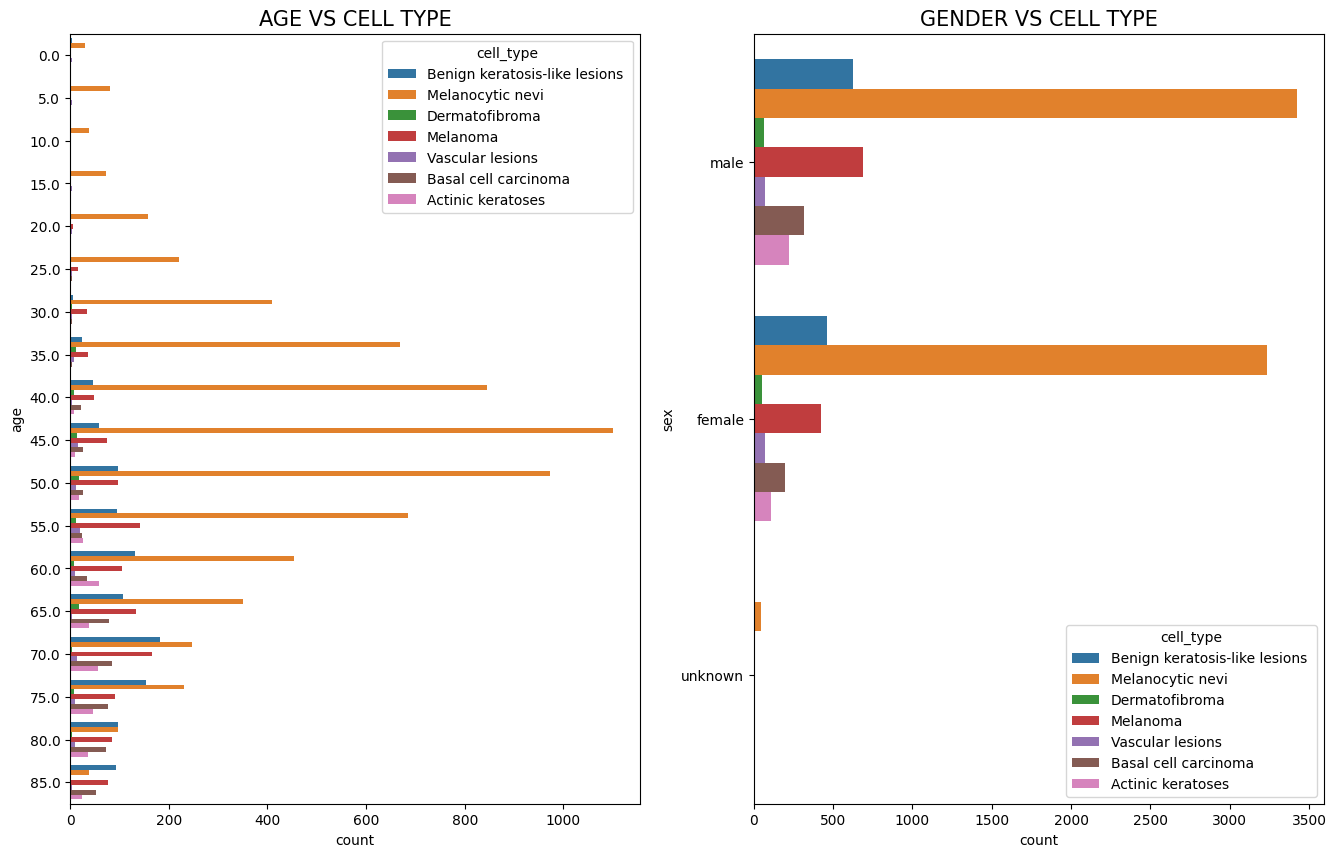

In [19]:
plt.figure(figsize=(25,10))
plt.subplot(131)
plt.title('AGE VS CELL TYPE',fontsize = 15)
sns.countplot(y='age', hue='cell_type',data=df)
plt.subplot(132)
plt.title('GENDER VS CELL TYPE',fontsize = 15)
sns.countplot(y='sex', hue='cell_type',data=df)

The age group between 0-75 years is infected the most by Melanocytic nevi. On the other hand, the people aged 80-90 are affected more by Benign keratosis-like lesions.

All the gender groups are affected the most by Melanocytic nevi.

In [20]:
features=df.drop(columns=['cell_type_idx'],axis=1)
target=df['cell_type_idx']

In [21]:
features.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,image
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,Benign keratosis-like lesions,"[[[187, 150, 192], [190, 154, 195], [192, 156,..."
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,Benign keratosis-like lesions,"[[[24, 13, 22], [25, 13, 23], [24, 14, 23], [2..."
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,Benign keratosis-like lesions,"[[[186, 127, 135], [188, 129, 137], [191, 135,..."
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,Benign keratosis-like lesions,"[[[23, 11, 15], [24, 11, 18], [24, 10, 19], [2..."
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,Benign keratosis-like lesions,"[[[125, 83, 105], [132, 89, 112], [138, 93, 11..."


In [22]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

x_train_o, x_test_o, y_train_o, y_test_o = train_test_split(features, target, test_size=0.25,random_state=666)
tf.unique(x_train_o.cell_type.values)

Unique(y=<tf.Tensor: shape=(7,), dtype=string, numpy=
array([b'Melanocytic nevi', b'Basal cell carcinoma', b'Melanoma',
       b'Vascular lesions', b'Benign keratosis-like lesions ',
       b'Actinic keratoses', b'Dermatofibroma'], dtype=object)>, idx=<tf.Tensor: shape=(7511,), dtype=int32, numpy=array([0, 1, 0, ..., 1, 0, 0], dtype=int32)>)

In [23]:
x_train = np.asarray(x_train_o['image'].tolist())
x_test = np.asarray(x_test_o['image'].tolist())

x_train_mean = np.mean(x_train)
x_train_std = np.std(x_train)

x_test_mean = np.mean(x_test)
x_test_std = np.std(x_test)

x_train = (x_train - x_train_mean)/x_train_std
x_test = (x_test - x_test_mean)/x_test_std

In [24]:
# Perform one-hot encoding on the labels
y_train = to_categorical(y_train_o, num_classes = 7)
y_test = to_categorical(y_test_o, num_classes = 7)
y_test

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]])

In [25]:
x_train, x_validate, y_train, y_validate = train_test_split(x_train, y_train, test_size = 0.1, random_state = 999)
x_train = x_train.reshape(x_train.shape[0], *(128, 128, 3))
x_test = x_test.reshape(x_test.shape[0], *(128, 128, 3))
x_validate = x_validate.reshape(x_validate.shape[0], *(128, 128, 3))

In [26]:
# Flatten the training data
x_train_flat = x_train.reshape(x_train.shape[0], -1)

# Flatten the validation data
x_validate_flat = x_validate.reshape(x_validate.shape[0], -1)

# Flatten the test data
x_test_flat = x_test.reshape(x_test.shape[0], -1)


In [27]:
# from sklearn.preprocessing import StandardScaler
# # Initialize the scaler
# scaler = StandardScaler()

# # Fit and transform the scaler on the training data
# X_train_scaled = scaler.fit_transform(x_train_flat)

# # Transform the validation and test data using the same scaler
# X_validate_scaled = scaler.transform(x_validate_flat)
# X_test_scaled = scaler.transform(x_test_flat)


In [ ]:
# from tensorflow.keras.applications import MobileNet
# from tensorflow.keras.models import Model
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split
# from xgboost import XGBClassifier
# import xgboost as xgb
# import numpy as np

# # Load the pre-trained MobileNet model without the top layer
# base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# # Create a model that outputs the features from MobileNet
# model = Model(inputs=base_model.input, outputs=base_model.layers[-1].output)

# # Extract features from the training dataset using MobileNet
# features_train = model.predict(x_train)
# features_train = features_train.reshape(features_train.shape[0], -1)  # Flatten to a 2D array for XGBoost

# # Normalize features using StandardScaler
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(features_train)

# # Split the dataset into training and validation sets
# x_train, x_validate, y_train, y_validate = train_test_split(X_train_scaled, y_train, test_size=0.1, random_state=999)

# # Extract features from the test dataset using MobileNet
# features_test = model.predict(x_test)
# features_test = features_test.reshape(features_test.shape[0], -1)  # Flatten to a 2D array
# X_test_scaled = scaler.transform(features_test)

# # Parameters for XGBoost
# params = {
#     'objective': 'multi:softmax',
#     'num_class': len(set(y_train)),  # Number of classes in your dataset
#     'learning_rate': 0.1,
#     'max_depth': 6,
#     'eval_metric': 'mlogloss'
# }

# # Initialize a DMatrix for the test data (for evaluation purposes)
# dtest = xgb.DMatrix(X_test_scaled, label=y_test)

# # Set up the batch size
# batch_size = 2  # Adjust the batch size based on your available memory

# # Initialize the booster to None for the first iteration
# booster = None

# # Loop over the training data in batches
# for start in range(0, x_train.shape[0], batch_size):
#     end = min(start + batch_size, x_train.shape[0])
#     print(f"Training on batch from {start} to {end}...")

#     # Create a DMatrix for the current batch
#     dtrain = xgb.DMatrix(x_train[start:end], label=y_train[start:end])

#     # Train the model on the current batch
#     booster = xgb.train(
#         params,
#         dtrain,
#         num_boost_round=10,  # Number of boosting rounds for each batch
#         xgb_model=booster,  # Pass the previous booster to continue training
#         evals=[(dtest, 'test')],
#         verbose_eval=True
#     )

# # Save the final model
# booster.save_model('xgboost_final_model.json')

# # Make predictions on the test set
# predictions = booster.predict(dtest)

# # Evaluate the accuracy of the predictions
# accuracy = np.mean(predictions == y_test)
# print(f"XGBoost Classification accuracy: {accuracy * 100:.2f}%")
